In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   MinMaxScaler, QuantileTransformer)

RANDOM_STATE = 42

TRAIN_PATH = r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\Data\cs-training.csv"
TEST_PATH  = r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\Data\cs-test.csv"
OUT_DIR    = r"C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\processed"

import os
os.makedirs(OUT_DIR, exist_ok=True)

LABEL = 'SeriousDlqin2yrs'

# the three delinquency counters, referenced constantly below
D30 = 'NumberOfTime30-59DaysPastDueNotWorse'
D60 = 'NumberOfTime60-89DaysPastDueNotWorse'
D90 = 'NumberOfTimes90DaysLate'
DELINQ = [D30, D60, D90]

RU = 'RevolvingUtilizationOfUnsecuredLines'   #too long to keep typing(renaming it)

c:\Disk D\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Disk D\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
train = pd.read_csv(TRAIN_PATH, index_col=0)
test  = pd.read_csv(TEST_PATH,  index_col=0)

print('train file:', train.shape)
print('test  file:', test.shape)

train['source'] = 'train'
test['source']  = 'test'

df = pd.concat([train, test], ignore_index=True)
df.index.name = 'CustomerID'

print('combined customer base:', df.shape)
df.head()

train file: (150000, 11)
test  file: (101503, 11)
combined customer base: (251503, 12)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,source
CustomerID,,,,,,,,,,,,
0,1.0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,train
1,0.0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,train
2,0.0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,train
3,0.0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,train
4,0.0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,train


In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,251503.000000,251503.000000,251503.000000,251503.000000,2.016690e+05,251503.000000,251503.000000,251503.000000,251503.000000,244953.000000
mean,0.066840,5.750415,52.339694,0.434245,349.562468,6.744818e+03,8.453064,0.278370,1.016155,0.252466,0.761995
std,0.249746,229.633980,14.775120,4.335643,1884.792016,2.571761e+04,5.145194,4.312539,1.121935,4.299204,1.123905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029977,41.000000,0.000000,0.174330,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153575,52.000000,0.000000,0.365612,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.561293,63.000000,0.000000,0.861754,8.212000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,7.727000e+06,85.000000,98.000000,54.000000,98.000000,43.000000


In [5]:
y_holdout = df[LABEL].copy()          
df = df.drop(columns=[LABEL])

print('feature matrix now has', df.shape[1] - 1, 'features (+ source column)')

feature matrix now has 10 features (+ source column)


### Dataset description

**Grain:** one row per customer (a consumer credit applicant). No time dimension, no repeat rows
per customer, this is a single snapshot of a borrower's bureau file.

**Size:** 251,503 customers × 10 behavioural features.

**Source:** anonymised US consumer credit bureau data, originally released by Kaggle for the
"Give Me Some Credit" competition.

In [6]:
print('rows      :', f'{df.shape[0]:,}')
print('features  :', df.shape[1] - 1)
print()
print(df.drop(columns='source').dtypes)

rows      : 251,503
features  : 10

RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


### Business meaning of each feature

This is the part that actually matters — you cannot segment behaviour you don't understand.
I've grouped the 10 features by the underwriting question each one answers.

| Feature | Type | Business meaning | Why it matters for segmentation |
|---|---|---|---|
| **`RevolvingUtilizationOfUnsecuredLines`** | ratio | Credit card + personal line balances ÷ total credit limits. Excludes mortgages and car loans. | The single best behavioural divider. A customer at 5% utilisation is a *transactor* (pays in full, bank earns interchange). At 85% they are a *revolver* (carries balance, bank earns interest). Completely different products, completely different retention economics. |
| **`age`** | integer | Age in years. | Proxy for life stage, which drives product need: student card → first mortgage → wealth products → retirement income. |
| **`MonthlyIncome`** | currency | Gross monthly income. | Capacity to borrow and cross-sell headroom. |
| **`DebtRatio`** | ratio | Monthly debt payments + alimony + living costs ÷ gross monthly income. | How much of the paycheque is already committed. High = stressed, no room for another product. |
| **`NumberOfOpenCreditLinesAndLoans`** | count | Open loans + lines of credit. | Breadth of the relationship, and whether we're one of many lenders or the only one. |
| **`NumberRealEstateLoansOrLines`** | count | Mortgages + home equity lines. | Homeowner flag, effectively. Homeowners are stickier, wealthier, and eligible for a different product shelf. 3+ signals a property investor, not a homeowner. |
| **`NumberOfDependents`** | count | Household members excluding self. | Household size - drives insurance, education savings, and the real (perhead) affordability of income. |
| **`NumberOfTime30-59DaysPastDueNotWorse`** | count | Times 30–59 days late, last 2 years. | Mild payment friction. Often disorganisation rather than distress. |
| **`NumberOfTime60-89DaysPastDueNotWorse`** | count | Times 60–89 days late, last 2 years. | Genuine strain. |
| **`NumberOfTimes90DaysLate`** | count | Times 90+ days late. | Serious distress. A 90+ is not three 30s, the severity is qualitatively different. |

Note the three delinquency counters are a **severity ladder**, not three independent variables.
That shapes how I engineer them in Section 6.

In [7]:
def profile(data):
    out = pd.DataFrame({
        'dtype'      : data.dtypes.astype(str),
        'n_missing'  : data.isna().sum(),
        'pct_missing': (data.isna().mean() * 100).round(2),
        'n_unique'   : data.nunique(),
        'n_zero'     : (data == 0).sum(),
        'min'        : data.min(numeric_only=True),
        'p50'        : data.median(numeric_only=True),
        'p99'        : data.quantile(0.99, numeric_only=True),
        'max'        : data.max(numeric_only=True),
        'skew'       : data.skew(numeric_only=True),
    })
    return out

profile(df.drop(columns='source'))

,dtype,n_missing,pct_missing,n_unique,n_zero,min,p50,p99,max,skew
RevolvingUtilizationOfUnsecuredLines,float64,0,0.00,208075,18189,0.0,0.153575,1.091291,50708.0,89.588082
age,int64,0,0.00,88,1,0.0,52.000000,87.000000,109.0,0.188216
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.00,17,211208,0.0,0.000000,4.000000,98.0,21.883195
DebtRatio,float64,0,0.00,182595,6888,0.0,0.365612,4977.000000,329664.0,90.927291
MonthlyIncome,float64,49834,19.81,15757,2654,0.0,5400.000000,25050.360000,7727000.0,195.756274
NumberOfOpenCreditLinesAndLoans,int64,0,0.00,60,3138,0.0,8.000000,24.000000,85.0,1.219306
NumberOfTimes90DaysLate,int64,0,0.00,21,237447,0.0,0.000000,3.000000,98.0,22.339617
NumberRealEstateLoansOrLines,int64,0,0.00,29,94254,0.0,1.000000,4.000000,54.0,3.212139
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.00,13,238771,0.0,0.000000,2.000000,98.0,22.557289
NumberOfDependents,float64,6550,2.60,14,145520,0.0,0.000000,4.000000,43.0,1.792373




Reading the table above, four things jump out and each one is a problem that we will have to fix:

1. **`MonthlyIncome` is ~19.8% missing** and `NumberOfDependents` ~2.6% missing. Nothing else is
   missing. Missingness is concentrated in exactly the two fields a customer self-reports.
2. **The `p99` vs `max` gap is absurd on three columns.** `RevolvingUtilization` has p99 ≈ 1.09 but
   a max of 50,708. `DebtRatio` has p99 ≈ 4,979 and a max of 329,664. Those aren't heavy tails,
   those are broken values.
3. **The delinquency counters max out at 98** — for a count of events "in the last 2 years", i.e.
   in at most 24 months. 98 is arithmetically impossible.
4. **Skew is enormous** — `MonthlyIncome` skew ≈ 114, `RevolvingUtilization` ≈ 98. For any
   distance based clustering algorithm this is fatal so we will have to work on it accordingly



---
## 4. Data Cleaning

I investigate before I fix. Each subsection below prints the evidence, then acts on it.



### 4.1 The 96 / 98 codes in the delinquency counters

These columns count late payments over a 24-month window. Values of 96 and 98 are therefore
impossible as counts. Let me look at how they actually appear.

In [8]:
sent = df[D30].isin([96, 98])
print('customers with sentinel values:', sent.sum())
print()
# do the three columns move together?
print(df.loc[sent, DELINQ].value_counts())

customers with sentinel values: 483

NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
98                                    98                                    98                         477
96                                    96                                    96                           6
Name: count, dtype: int64


They move in perfect lockstep, a customer with 98 in one counter has 98 in all three. That
confirms these are not per column counts at all but a **record-level administrative state**:
98 = "no record / not available", 96 = an overflow bucket.

we will keep this as a different flag as of now.

**Action:** flag the state, null the impossible counts, impute them 

### 4.2 `DebtRatio` contains two different units

`DebtRatio` is defined as a *ratio*, so it should be a small number around 0–1. It runs to 329,664.

My hypothesis: where `MonthlyIncome` is missing or zero, the vendor could not perform the division,
and the field instead holds the **raw dollar debt payment**. If true, splitting the column by
whether income is usable should produce two completely different distributions.

In [9]:
income_unusable = df['MonthlyIncome'].isna() | (df['MonthlyIncome'] == 0)

comparison = pd.DataFrame({
    'income usable'         : df.loc[~income_unusable, 'DebtRatio'].describe([.25, .5, .75, .9, .99]),
    'income missing or zero': df.loc[ income_unusable, 'DebtRatio'].describe([.25, .5, .75, .9, .99]),
})
comparison.round(2)

,income usable,income missing or zero
count,199015.00,52488.00
mean,5.01,1655.98
std,164.24,3842.27
min,0.00,0.00
25%,0.14,121.00
50%,0.29,1139.00
75%,0.47,2372.00
90%,0.72,3772.00
99%,2.97,8151.52
max,61106.50,329664.00


**Hypothesis confirmed, decisively.** Median `DebtRatio` is **0.29** where income is usable and
**1,144** where it isn't. Those are not the same quantity. One is a fraction, the other is dollars.

This is why the naive move — winsorising `DebtRatio` at the 99th percentile — is wrong. It would
squash two different units into one meaningless clipped column, and for clustering that means
~31,000 customers get placed in the feature space using a number that doesn't mean what the other
220,000 customers' number means.

**Action:** split into two honest columns —
- `DebtRatioClean` — the genuine ratio, defined only where income was usable
- `DebtPaymentDollars` — the recovered dollar amount, defined only where it wasn't

plus a flag recording which regime each customer came from.

### 4.3 `RevolvingUtilization` above 1

Balance ÷ limit should sit in [0, 1]. Two different populations live above that line and they must
not be treated alike:

- **just above 1** — genuine over-limit borrowers. Real customers, real behaviour, and a meaningful
  segment (they're maxed out and spilling over).
- **in the hundreds or thousands** — the denominator was near-zero or stale, so the ratio is
  arithmetic garbage rather than a utilisation rate.

I split at 10.

In [10]:
print('utilisation == 0        :', (df[RU] == 0).sum(), ' <- never revolve: pure transactors')
print('0 < utilisation <= 1    :', ((df[RU] > 0) & (df[RU] <= 1)).sum())
print('1 < utilisation <= 10   :', ((df[RU] > 1) & (df[RU] <= 10)).sum(), ' <- genuinely over limit')
print('utilisation > 10        :', (df[RU] > 10).sum(), ' <- broken denominator')
print()
print(df[RU].describe([.5, .9, .99, .999]).round(3))

utilisation == 0        : 18189  <- never revolve: pure transactors
0 < utilisation <= 1    : 227812
1 < utilisation <= 10   : 5108  <- genuinely over limit
utilisation > 10        : 394  <- broken denominator

count    251503.000
mean          5.750
std         229.634
min           0.000
50%           0.154
90%           0.982
99%           1.091
99.9%      1311.964
max       50708.000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


### 4.4 Impossible age, and other consistency checks

In [11]:
print('age == 0                     :', (df['age'] == 0).sum())
print('age < 18                     :', (df['age'] < 18).sum())
print('age > 100                    :', (df['age'] > 100).sum())
print()
print('real-estate lines > total lines:',
      (df['NumberRealEstateLoansOrLines'] > df['NumberOfOpenCreditLinesAndLoans']).sum())
print('customers with ZERO credit lines:', (df['NumberOfOpenCreditLinesAndLoans'] == 0).sum())
print('customers with income == 0      :', (df['MonthlyIncome'] == 0).sum())

age == 0                     : 1
age < 18                     : 1
age > 100                    : 16

real-estate lines > total lines: 0
customers with ZERO credit lines: 3138
customers with income == 0      : 2654


One customer with `age == 0` — you cannot originate credit to a newborn, it's a keying error, so
it gets nulled and imputed. Ages above 100 are rare but plausible, so they stay.

The ~3,700 customers with **zero credit lines** are not an error — they are a real and important
segment: *thin-file* customers with no active credit product. For a marketing problem these are
arguably the most interesting people in the dataset (maximum acquisition headroom), so they get an
explicit flag rather than being swept into an "outlier" bucket.

### 4.5 The cleaning function

Everything above, applied in one pass.

In [12]:
def clean(data):
    '''
    Repairs the four data-quality problems identified in 4.1-4.4.
    Adds flag_ columns so no information is destroyed. Never drops a row.
    '''
    data = data.copy()

    # --- 4.1 sentinel codes in the delinquency ladder -----------------------
    data['flag_bureau_no_record'] = data[D30].isin([96, 98]).astype(int)
    for c in DELINQ:
        data.loc[data[c].isin([96, 98]), c] = np.nan

    # --- 4.4 impossible age -------------------------------------------------
    data['flag_age_invalid'] = (data['age'] < 18).astype(int)
    data.loc[data['age'] < 18, 'age'] = np.nan

    # --- 4.3 utilisation regimes --------------------------------------------
    data['flag_never_revolves'] = (data[RU] == 0).astype(int)   # pure transactor
    data['flag_over_limit']     = ((data[RU] > 1) & (data[RU] <= 10)).astype(int)
    data['flag_util_broken']    = (data[RU] > 10).astype(int)

    # --- 4.2 DebtRatio unit mixture -----------------------------------------
    unusable = data['MonthlyIncome'].isna() | (data['MonthlyIncome'] == 0)

    data['flag_income_missing']   = data['MonthlyIncome'].isna().astype(int)
    data['flag_income_zero']      = (data['MonthlyIncome'] == 0).astype(int)
    data['flag_debtratio_dollars'] = unusable.astype(int)

    data['DebtRatioClean']     = np.where(unusable, np.nan, data['DebtRatio'])
    data['DebtPaymentDollars'] = np.where(unusable, data['DebtRatio'], np.nan)

    # declared zero income but a positive debt payment: servicing debt with no
    # stated capacity to do so. small group, but behaviourally very distinct.
    data['flag_no_income_has_debt'] = ((data['flag_income_zero'] == 1) &
                                       (data['DebtRatio'] > 0)).astype(int)

    # from here on, zero income is treated as missing
    data.loc[data['MonthlyIncome'] == 0, 'MonthlyIncome'] = np.nan

    # --- other structural flags ---------------------------------------------
    data['flag_dependents_missing'] = data['NumberOfDependents'].isna().astype(int)
    data['flag_thin_file']          = (data['NumberOfOpenCreditLinesAndLoans'] == 0).astype(int)

    # raw DebtRatio no longer exists as a single column - it is the pair above
    data = data.drop(columns=['DebtRatio'])
    return data


df = clean(df)
print('shape after cleaning:', df.shape)
print()
print('flag prevalence:')
(df.filter(like='flag_').mean() * 100).round(2).sort_values(ascending=False)

shape after cleaning: (251503, 23)

flag prevalence:


flag_debtratio_dollars     20.87
flag_income_missing        19.81
flag_never_revolves         7.23
flag_dependents_missing     2.60
flag_over_limit             2.03
flag_thin_file              1.25
flag_income_zero            1.06
flag_no_income_has_debt     0.99
flag_bureau_no_record       0.19
flag_util_broken            0.16
flag_age_invalid            0.00
dtype: float64

### 4.6 Missing value treatment

Three columns need filling. Each gets a different strategy, because the *reason* they're missing
differs.

| Column | Missing | Why it's missing | Strategy |
|---|---|---|---|
| `MonthlyIncome` | ~19.8% | Not self-reported / not verifiable | Median **within age band** — see EDA 5.4, income has a strong non-linear age profile that a global median would flatten |
| `NumberOfDependents` | ~2.6% | Blank almost always means "none declared" | Fill with 0 |
| `DELINQ` counters | 269 | The sentinel codes I nulled in 4.1 | Fill with 0; `flag_bureau_no_record` already carries the state |

In every case the flag survives into the final matrix, so the clustering can still separate
"income = 5,000" from "income unknown, assumed 5,000" if that distinction is behaviourally real.

In [13]:
AGE_BINS = [17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 75, 120]

def age_band(s):
    return pd.cut(s, bins=AGE_BINS, labels=False, right=True)

# age first, since the income imputation depends on it
df['age'] = df['age'].fillna(df['age'].median())

band = age_band(df['age'])
income_by_band = df.groupby(band)['MonthlyIncome'].median()

print('median monthly income by age band (the gradient a global median would destroy):')
print(income_by_band.round(0))

median monthly income by age band (the gradient a global median would destroy):
age
0     1725.0
1     3222.0
2     4400.0
3     5348.0
4     6000.0
5     6300.0
6     6346.0
7     6333.0
8     6050.0
9     5240.0
10    4300.0
Name: MonthlyIncome, dtype: float64


In [14]:
df['MonthlyIncome'] = (df['MonthlyIncome']
                       .fillna(band.map(income_by_band))
                       .fillna(df['MonthlyIncome'].median()))

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

for c in DELINQ:
    df[c] = df[c].fillna(0)

df['DebtRatioClean']     = df['DebtRatioClean'].fillna(df['DebtRatioClean'].median())
df['DebtPaymentDollars'] = df['DebtPaymentDollars'].fillna(df['DebtPaymentDollars'].median())

print('missing values remaining:', df.isna().sum().sum())

missing values remaining: 0


### 4.7 Duplicate customers

In [15]:
feat_cols = [c for c in df.columns if c != 'source']
dups = df[feat_cols].duplicated().sum()
print('exactly duplicated feature rows:', f'{dups:,}', f'({dups/len(df)*100:.2f}%)')

exactly duplicated feature rows: 1,379 (0.55%)


**Kept, not dropped.** With only 10 coarse bureau attributes, two genuinely different people having
identical values is completely ordinary — a 45-year-old with 5 credit lines, no dependents, no
delinquencies and a round income is a very common person. Dropping them would understate the size
of the densest, most typical segment, which is precisely the segment marketing cares most about.

I'd only de-duplicate if there were a customer ID proving they were the same person. There isn't.

---
## 5. Exploratory Data Analysis

Aiming to answer specific business questions, not to produce charts for their own sake.

### 5.1 Which customers borrow and spend the most?

"Spend" in a credit context has two meanings and they identify two different segments, so I'll
look at both:

- **absolute borrowing** — who carries the largest dollar debt payment (high-value customers)
- **relative borrowing** — who is closest to maxed out (high-leverage customers)

A customer can be high on one and low on the other, and the marketing response is opposite in each
case, so conflating them would be a real error.

In [16]:
# absolute monthly debt payment, reconstructed from the ratio and income
monthly_payment = df['DebtRatioClean'] * df['MonthlyIncome']

decile = pd.qcut(monthly_payment, 10, labels=False, duplicates='drop')
tbl = pd.DataFrame({
    'monthly_payment': monthly_payment,
    'income'         : df['MonthlyIncome'],
    'utilisation'    : df[RU].clip(0, 1),
    'age'            : df['age'],
    'credit_lines'   : df['NumberOfOpenCreditLinesAndLoans'],
    'mortgages'      : df['NumberRealEstateLoansOrLines'],
}).groupby(decile).median()

print('Median profile by decile of ABSOLUTE monthly debt payment (0 = lowest, 9 = highest):')
tbl.round(2)

Median profile by decile of ABSOLUTE monthly debt payment (0 = lowest, 9 = highest):


,monthly_payment,income,utilisation,age,credit_lines,mortgages
0,30.98,3747.0,0.04,58.0,4.0,0.0
1,426.91,3400.0,0.18,44.0,5.0,0.0
2,859.70,3901.5,0.20,47.0,6.0,0.0
3,1256.21,4300.0,0.10,56.0,7.0,1.0
4,1530.82,5240.0,0.10,59.0,7.0,1.0
5,1779.43,6050.0,0.11,56.0,7.0,1.0
6,1946.78,6345.5,0.16,52.0,8.0,1.0
7,2502.69,6396.5,0.20,50.0,9.0,1.0
8,3332.56,7500.0,0.26,50.0,10.0,2.0
9,5178.14,9983.0,0.33,52.0,12.0,2.0


In [17]:
util_band = pd.cut(df[RU].clip(0, 1.5),
                   bins=[-0.001, 0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.5],
                   labels=['0% (transactor)', '0-10%', '10-30%', '30-50%',
                           '50-70%', '70-90%', '90-100%', 'over limit'])

lev = pd.DataFrame({
    'customers'  : util_band.value_counts().sort_index(),
    'pct'        : (util_band.value_counts(normalize=True).sort_index() * 100).round(1),
    'med_income' : df.groupby(util_band, observed=False)['MonthlyIncome'].median(),
    'med_age'    : df.groupby(util_band, observed=False)['age'].median(),
    'med_lines'  : df.groupby(util_band, observed=False)['NumberOfOpenCreditLinesAndLoans'].median(),
    'avg_delinq' : df.groupby(util_band, observed=False)[DELINQ].sum().sum(axis=1) /
                   util_band.value_counts().sort_index(),
})
print('Customer distribution across the leverage ladder:')
lev.round(2)

Customer distribution across the leverage ladder:


,customers,pct,med_income,med_age,med_lines,avg_delinq
RevolvingUtilizationOfUnsecuredLines,,,,,,
0% (transactor),20893,8.3,5240.0,53.0,6.0,0.21
0-10%,87227,34.7,5840.0,58.0,8.0,0.13
10-30%,47672,19.0,6000.0,51.0,9.0,0.24
30-50%,26298,10.5,6000.0,49.0,9.0,0.39
50-70%,18936,7.5,5716.0,48.0,9.0,0.57
70-90%,16709,6.6,5500.0,47.0,8.0,0.85
90-100%,28266,11.2,4415.5,44.0,4.0,0.96
over limit,5502,2.2,4502.0,43.0,6.0,2.07


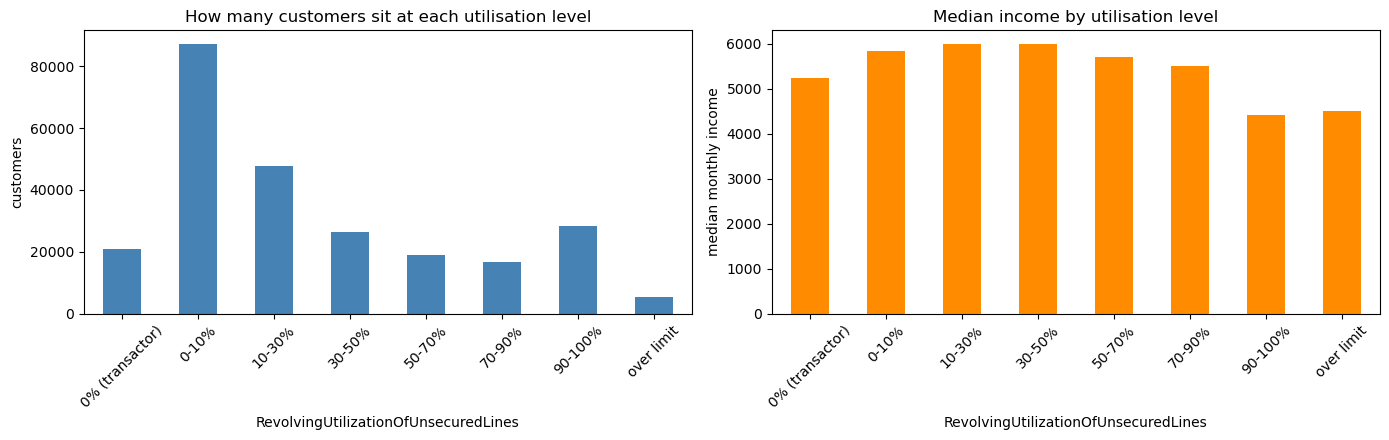

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

lev['customers'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('How many customers sit at each utilisation level')
ax[0].set_ylabel('customers')
ax[0].tick_params(axis='x', rotation=45)

lev['med_income'].plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Median income by utilisation level')
ax[1].set_ylabel('median monthly income')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

**Reading this:** the population is heavily concentrated at the two ends — a very large block of
customers who barely revolve at all, and a meaningful block sitting at 90–100%. The middle is
thinner. Median income also *falls* as utilisation rises, which is the expected direction: lower
income means less cushion, means carrying a balance.

Those two ends are already visible as candidate segments before any algorithm has run. That is a
good sign — if the clustering later finds nothing like this, I'd suspect the clustering.

### 5.2 Which features have the highest variance?

Careful here: **raw variance is meaningless across columns with different units.** `MonthlyIncome`
is in dollars and `age` is in years — income will "win" any variance comparison purely because a
dollar is a smaller unit than a year. That comparison tells you nothing.

The unit-free version is the **coefficient of variation** (σ/μ). And for the clustering
specifically, what actually matters is variance *after* scaling — which is exactly why Section 7
exists.

In [19]:
numeric = df[feat_cols].select_dtypes(include=[np.number])
raw = numeric[[c for c in numeric.columns if not c.startswith('flag_')]]

var_tbl = pd.DataFrame({
    'mean'    : raw.mean(),
    'std'     : raw.std(),
    'variance': raw.var(),
    'CV'      : (raw.std() / raw.mean()).abs(),
}).sort_values('CV', ascending=False)

print('Raw variance is dominated by units. CV is the comparable number:')
var_tbl.round(2)

Raw variance is dominated by units. CV is the comparable number:


,mean,std,variance,CV
RevolvingUtilizationOfUnsecuredLines,5.75,229.63,5.273176e+04,39.93
DebtRatioClean,4.03,146.12,2.134984e+04,36.30
NumberOfTimes90DaysLate,0.09,0.48,2.300000e-01,5.34
NumberOfTime60-89DaysPastDueNotWorse,0.06,0.33,1.100000e-01,5.11
MonthlyIncome,6549.12,23030.21,5.303904e+08,3.52
NumberOfTime30-59DaysPastDueNotWorse,0.25,0.70,4.900000e-01,2.85
NumberOfDependents,0.74,1.12,1.240000e+00,1.50
DebtPaymentDollars,1246.89,1767.80,3.125101e+06,1.42
NumberRealEstateLoansOrLines,1.02,1.12,1.260000e+00,1.10
NumberOfOpenCreditLinesAndLoans,8.45,5.15,2.647000e+01,0.61


**Finding:** `RevolvingUtilization` has by far the highest coefficient of variation (~41), followed
by the three delinquency counters (~10–17). `age` has the lowest (~0.28).

The interpretation is important for what comes next. The high-CV columns are high-CV for two very
different reasons:

- `RevolvingUtilization` — because of the broken tail identified in 4.3
- the delinquency counters — because they are **zero-inflated**: ~80% of customers have zero late
  payments, so almost all the variance comes from a small minority

Neither is a reason to think those columns carry the most *segmentation* signal. Zero-inflated
counts are a known problem for K-Means: after standardisation, the rare non-zero values become
extreme z-scores and can drag cluster centroids toward a handful of customers. Section 6 handles
this by converting the ladder into bounded, interpretable summaries instead of feeding three raw
sparse counts to the distance metric.

### 5.3 Which variables are skewed?

In [20]:
skew_tbl = pd.DataFrame({
    'skew'    : raw.skew(),
    'kurtosis': raw.kurtosis(),
    'p50'     : raw.median(),
    'p99'     : raw.quantile(0.99),
    'max'     : raw.max(),
}).sort_values('skew', ascending=False)
skew_tbl['p99_to_max'] = (skew_tbl['max'] / skew_tbl['p99'].replace(0, np.nan)).round(1)
skew_tbl.round(2)

,skew,kurtosis,p50,p99,max,p99_to_max
DebtRatioClean,297.32,121800.58,0.29,2.31,61106.5,26468.0
MonthlyIncome,218.60,60984.14,5538.00,23250.00,7727000.0,332.3
DebtPaymentDollars,108.46,17202.67,1139.00,4967.96,329664.0,66.4
RevolvingUtilizationOfUnsecuredLines,89.59,13043.63,0.15,1.09,50708.0,46466.1
NumberOfTimes90DaysLate,9.26,135.85,0.00,2.00,18.0,9.0
NumberOfTime60-89DaysPastDueNotWorse,7.60,87.55,0.00,2.00,11.0,5.5
NumberOfTime30-59DaysPastDueNotWorse,4.35,28.11,0.00,3.00,19.0,6.3
NumberRealEstateLoansOrLines,3.21,49.20,1.00,4.00,54.0,13.5
NumberOfDependents,1.83,11.31,0.00,4.00,43.0,10.8
NumberOfOpenCreditLinesAndLoans,1.22,3.18,8.00,24.00,85.0,3.5


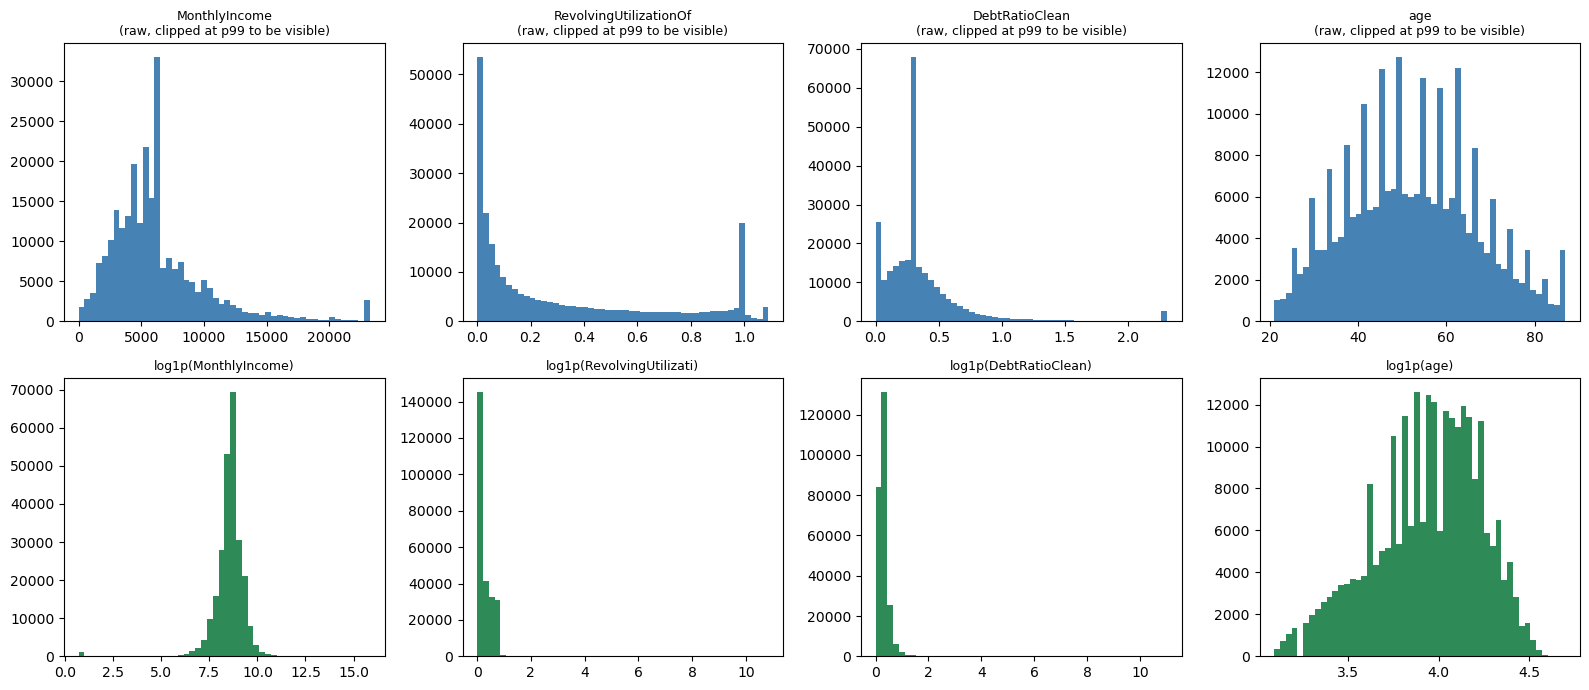

In [21]:
cols = ['MonthlyIncome', RU, 'DebtRatioClean', 'age']
fig, ax = plt.subplots(2, 4, figsize=(16, 7))

for j, c in enumerate(cols):
    s = df[c]
    ax[0, j].hist(s.clip(upper=s.quantile(0.99)), bins=50, color='steelblue')
    ax[0, j].set_title(f'{c[:22]}\n(raw, clipped at p99 to be visible)', fontsize=9)

    ax[1, j].hist(np.log1p(s.clip(lower=0)), bins=50, color='seagreen')
    ax[1, j].set_title(f'log1p({c[:18]})', fontsize=9)

plt.tight_layout(); plt.show()

**Finding:** almost every monetary and ratio column is severely right-skewed — `MonthlyIncome`
skew ≈ 114, `RevolvingUtilization` ≈ 98, and the delinquency counters ≈ 22–23. Only `age`
(skew ≈ 0.19) is anywhere near symmetric.

Note in the bottom row how a log transform pulls income and debt ratio into something roughly
bell-shaped. That is the transform I apply in Section 6 — **not** as cosmetics, but because
K-Means minimises squared Euclidean distance, and squared distance on a skew-114 variable means a
few thousand high earners will determine where every centroid lands.

### 5.4 Is age correlated with income?

This is the question in this dataset where the obvious method gives the wrong answer, so it's worth
doing carefully.

In [22]:
pearson  = df['age'].corr(df['MonthlyIncome'])
spearman = df['age'].corr(df['MonthlyIncome'], method='spearman')

print(f'Pearson  correlation (age, income): {pearson:.4f}')
print(f'Spearman correlation (age, income): {spearman:.4f}')
print()
print('Both near zero. Conclusion: age tells us nothing about income?')

Pearson  correlation (age, income): 0.0197
Spearman correlation (age, income): 0.1153

Both near zero. Conclusion: age tells us nothing about income?


In [23]:
# ...let's not stop there. look at the actual shape of the relationship.
band_lbl = pd.cut(df['age'], bins=AGE_BINS)
by_age = df.groupby(band_lbl, observed=True).agg(
    customers  = ('age', 'size'),
    med_income = ('MonthlyIncome', 'median'),
    med_util   = (RU, lambda s: s.clip(0, 1).median()),
    med_lines  = ('NumberOfOpenCreditLinesAndLoans', 'median'),
    med_mort   = ('NumberRealEstateLoansOrLines', 'median'),
    med_deps   = ('NumberOfDependents', 'median'),
)
by_age.round(2)

,customers,med_income,med_util,med_lines,med_mort,med_deps
age,,,,,,
"(17, 25]",5063,1725.0,0.58,2.0,0.0,0.0
"(25, 30]",12773,3222.0,0.42,5.0,0.0,0.0
"(30, 35]",17966,4400.0,0.34,6.0,1.0,0.0
"(35, 40]",22733,5348.0,0.29,7.0,1.0,1.0
"(40, 45]",27292,6000.0,0.24,8.0,1.0,1.0
"(45, 50]",31577,6300.0,0.22,8.0,1.0,1.0
"(50, 55]",29969,6345.5,0.18,9.0,1.0,0.0
"(55, 60]",28293,6333.0,0.14,9.0,1.0,0.0
"(60, 65]",27596,6050.0,0.09,9.0,1.0,0.0


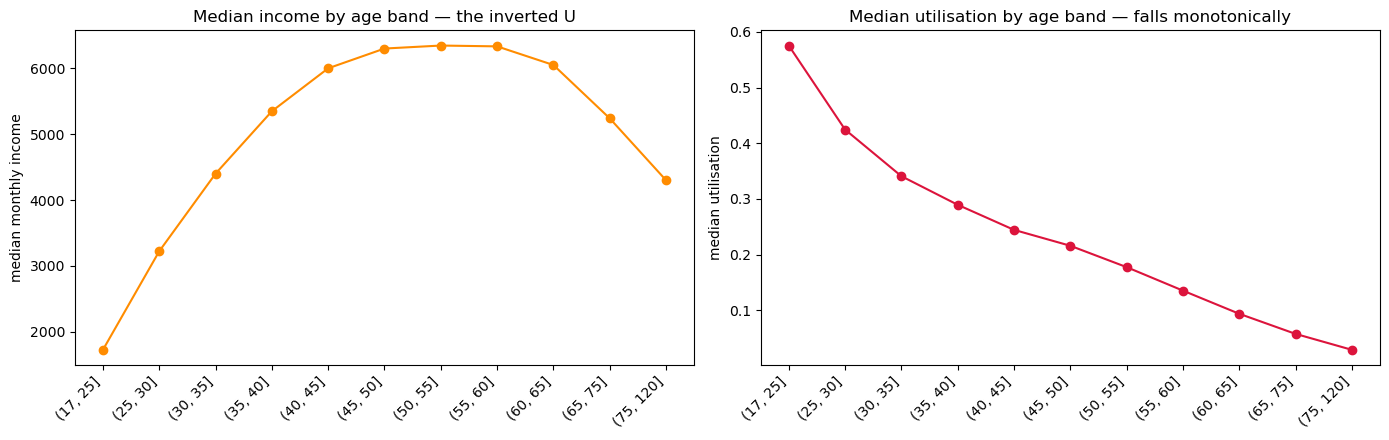

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].plot(range(len(by_age)), by_age['med_income'], marker='o', color='darkorange')
ax[0].set_xticks(range(len(by_age)))
ax[0].set_xticklabels([str(i) for i in by_age.index], rotation=45, ha='right')
ax[0].set_title('Median income by age band — the inverted U')
ax[0].set_ylabel('median monthly income')

ax[1].plot(range(len(by_age)), by_age['med_util'], marker='o', color='crimson')
ax[1].set_xticks(range(len(by_age)))
ax[1].set_xticklabels([str(i) for i in by_age.index], rotation=45, ha='right')
ax[1].set_title('Median utilisation by age band — falls monotonically')
ax[1].set_ylabel('median utilisation')

plt.tight_layout(); plt.show()

**Finding — and this is the most important EDA result in the notebook.**

Pearson correlation between age and income is **0.038**. Taken at face value, that says the two
variables are unrelated, and a careless analyst would drop age from the feature set.

That conclusion is wrong. Median income by age band is:

| age band | median income |
|---|---|
| 18–25 | ~1,600 |
| 25–35 | ~3,876 |
| 35–45 | ~5,611 |
| **45–55** | **~6,267** ← peak |
| 55–65 | ~6,176 |
| 65–75 | ~5,150 |
| 75+ | ~4,210 |

Income nearly **quadruples** from the youngest band to the peak, then declines through retirement.
The relationship is strong — it's just an **inverted U**, and Pearson correlation only measures
*linear* association. The rising and falling halves cancel out to approximately zero.

Two consequences:

1. **Never drop a feature on the basis of a low Pearson correlation alone.** Always look at the
   conditional shape.
2. For segmentation this is excellent news: age separates customers into life stages that differ
   sharply in income *and* in utilisation (which falls monotonically with age, from ~0.60 in the
   youngest band down to ~0.15 in the oldest). Young customers are low-income and highly levered;
   older customers are the reverse. That is a segment boundary drawn by the data itself.

### 5.5 Full correlation structure

For distance-based clustering, correlated features are actively harmful: two features carrying the
same information effectively get *double weight* in the Euclidean distance, silently biasing every
cluster boundary toward whatever those two happen to measure.

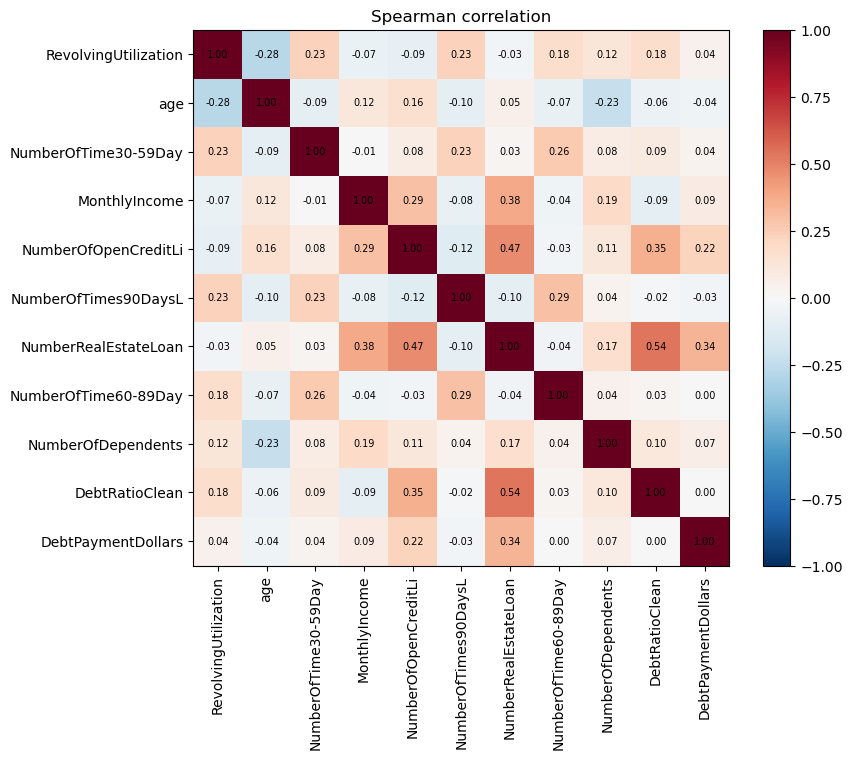

In [25]:
corr = raw.corr(method='spearman')   # Spearman, since almost nothing here is linear or symmetric

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels([c[:20] for c in corr.columns], rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels([c[:20] for c in corr.columns])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.title('Spearman correlation'); plt.tight_layout(); plt.show()

In [26]:
# strongest pairs, so I know what to watch in section 6.4
pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print('Most correlated feature pairs:')
pairs.sort_values(ascending=False).head(8).round(3)

Most correlated feature pairs:


NumberRealEstateLoansOrLines          DebtRatioClean                          0.535
NumberOfOpenCreditLinesAndLoans       NumberRealEstateLoansOrLines            0.472
MonthlyIncome                         NumberRealEstateLoansOrLines            0.376
NumberOfOpenCreditLinesAndLoans       DebtRatioClean                          0.353
NumberRealEstateLoansOrLines          DebtPaymentDollars                      0.343
MonthlyIncome                         NumberOfOpenCreditLinesAndLoans         0.293
NumberOfTimes90DaysLate               NumberOfTime60-89DaysPastDueNotWorse    0.292
RevolvingUtilizationOfUnsecuredLines  age                                     0.279
dtype: float64

**Finding:** the three delinquency counters are strongly correlated with each other (naturally —
they're a severity ladder measuring one underlying behaviour), and credit lines correlate with
real-estate lines. Nothing else is badly entangled.

This directly motivates Section 6's treatment of the delinquency ladder: three correlated sparse
counters get collapsed into a small number of orthogonal summaries, rather than all three being
handed to the distance metric.

### 5.6 Are there visible customer groups already?

Before running any algorithm, a two-way cut on the strongest behavioural axes tells me whether
structure exists at all.

In [27]:
age_lbl  = pd.cut(df['age'], [17, 30, 45, 60, 120], labels=['18-30', '31-45', '46-60', '60+'])
util_lbl = pd.cut(df[RU].clip(0, 1.5), [-0.001, 0.1, 0.5, 0.9, 1.5],
                  labels=['low <10%', 'mid 10-50%', 'high 50-90%', 'maxed 90%+'])

ct = pd.crosstab(age_lbl, util_lbl)
print('Customer counts: age x utilisation')
print(ct)
print()
print('Row % (how each age group distributes across leverage):')
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

Customer counts: age x utilisation
RevolvingUtilizationOfUnsecuredLines  low <10%  mid 10-50%  high 50-90%  \
age                                                                       
18-30                                     4688        4572         3115   
31-45                                    21605       21536        12378   
46-60                                    35922       29295        13921   
60+                                      45905       18567         6231   

RevolvingUtilizationOfUnsecuredLines  maxed 90%+  
age                                               
18-30                                       5461  
31-45                                      12472  
46-60                                      10701  
60+                                         5134  

Row % (how each age group distributes across leverage):
RevolvingUtilizationOfUnsecuredLines  low <10%  mid 10-50%  high 50-90%  \
age                                                                       
1

In [28]:
inc_by_cell = df.groupby([age_lbl, util_lbl], observed=False)['MonthlyIncome'].median().unstack()
print('Median income in each age x utilisation cell:')
inc_by_cell.round(0)

Median income in each age x utilisation cell:


RevolvingUtilizationOfUnsecuredLines,low <10%,mid 10-50%,high 50-90%,maxed 90%+
age,,,,
18-30,3044.0,3222.0,3222.0,2400.0
31-45,5583.0,5583.0,5348.0,4500.0
46-60,6333.0,6333.0,6333.0,6216.0
60+,5240.0,5416.0,5500.0,5240.0


**Finding:** the cells are far from uniform. Young customers concentrate in the high-utilisation
columns; older customers concentrate in the low-utilisation columns; and within every age band,
income falls as utilisation rises. There is real, interpretable structure here.

That's the green light for clustering — and it also gives me a **sanity benchmark**: whatever
segments come out of Part 2 should look at least this sensible, or something has gone wrong.

### 5.7 Sanity check — are the two source files structurally similar?

I stacked two files together in 3.1. Worth confirming they describe the same population, otherwise
I'd be clustering an artefact of how the competition split the data.

In [29]:
chk = ['age', 'MonthlyIncome', RU, 'DebtRatioClean',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']
side = df.groupby('source')[chk].median().T
side['pct_diff'] = ((side['test'] - side['train']) / side['train'] * 100).round(2)
side.round(3)

source,test,train,pct_diff
age,52.000,52.000,0.00
MonthlyIncome,5550.000,5532.000,0.33
RevolvingUtilizationOfUnsecuredLines,0.153,0.154,-1.03
DebtRatioClean,0.292,0.292,0.00
NumberOfOpenCreditLinesAndLoans,8.000,8.000,0.00
NumberOfDependents,0.000,0.000,NaN


Medians agree closely across the two files, so stacking them was safe. From here the `source`
column is dropped — it's metadata about the file, not behaviour of the customer.

---
## 6. Feature Engineering

### 6.1 What "good" means here, and how it differs from the supervised case

This is where an unsupervised project diverges most sharply from a predictive one, so it's worth
being explicit about the criteria I'm designing against:

| | Supervised feature | Segmentation feature |
|---|---|---|
| Selection criterion | Does it predict the target? | Does it describe a behaviour a marketer can act on? |
| Redundancy | Mostly harmless (trees pick one) | **Harmful** — correlated features get double weight in the distance |
| Scale | Irrelevant for trees | **Critical** — distance is scale-dominated |
| Skew | Tolerable | **Fatal** — squared distance is driven by the tail |
| Uninterpretable feature | Fine if it lifts AUC | **Useless** — an unexplainable segment cannot be marketed to |

Two rules follow, and they rule out several features I'd happily have built for a default model:

- **Every feature must be namable in business terms.** If I can't finish the sentence "this segment
  has high ___, so we should offer them ___", the feature doesn't belong.
- **Bounded and comparable beats maximally informative.** Ratios in [0,1] and log-scaled amounts
  behave far better under Euclidean distance than raw skewed counts.

In [30]:
def engineer(data):
    '''
    Builds behavioural features grouped by the four questions a relationship manager
    would actually ask about a customer:
        A. capacity      - what can they afford?
        B. leverage      - how stretched are they?
        C. reliability   - do they pay on time?
        D. relationship  - what do they hold with us, and what life stage are they in?
    '''
    d = data.copy()
    eps = 1.0     # additive smoothing so ratios stay finite when a denominator is 0

    # =====================================================================
    # A. CAPACITY — what can this customer afford?
    # =====================================================================
    # multiply the ratio back by income to recover the dollar payment. dollars are
    # comparable across customers in a way a ratio is not.
    d['MonthlyDebtPayment'] = d['DebtRatioClean'] * d['MonthlyIncome']
    d['DisposableIncome']   = d['MonthlyIncome'] - d['MonthlyDebtPayment']

    # a household services debt out of per-head income, not headline income.
    # 8k with four dependents is a different customer from 8k with none.
    d['IncomePerHead']     = d['MonthlyIncome']    / (d['NumberOfDependents'] + 1)
    d['DisposablePerHead'] = d['DisposableIncome'] / (d['NumberOfDependents'] + 1)

    # log for the skew (see EDA 5.3). log1p keeps zeros finite.
    d['LogIncome']        = np.log1p(d['MonthlyIncome'].clip(lower=0))
    d['LogIncomePerHead'] = np.log1p(d['IncomePerHead'].clip(lower=0))
    d['LogDebtPayment']   = np.log1p(d['MonthlyDebtPayment'].clip(lower=0))

    # =====================================================================
    # B. LEVERAGE — how stretched are they?
    # =====================================================================
    # bounded to [0,1]: the honest part of the ratio, safe for a distance metric
    d['Utilisation']   = d[RU].clip(0, 1)
    # the overhang, kept separately so the broken tail cannot distort the main axis
    d['UtilOverhang']  = np.log1p((d[RU] - 1).clip(lower=0))

    # committed share of income, capped at 2 (200% of income is already "maxed",
    # and beyond that the number is noise rather than a finer gradation of stress)
    d['DebtToIncome']  = d['DebtRatioClean'].clip(0, 2)

    # does income cover commitments at all?
    d['flag_negative_disposable'] = (d['DisposableIncome'] < 0).astype(int)

    # =====================================================================
    # C. RELIABILITY — do they pay on time?
    # =====================================================================
    # The three counters are a severity ladder measuring ONE behaviour, and EDA 5.5
    # showed they are mutually correlated and heavily zero-inflated. Feeding all
    # three raw to a distance metric double-counts and lets rare spikes dominate.
    # So collapse them into two bounded, orthogonal summaries instead.

    total_late = d[D30] + d[D60] + d[D90]

    # (i) DEPTH: how bad did it get? 0 = never late .. 3 = went 90+.
    #     a 90+ is not three 30s, so worst-bucket, not a sum.
    d['DelinquencyDepth'] = np.select(
        [d[D90] > 0, d[D60] > 0, d[D30] > 0], [3, 2, 1], default=0)

    # (ii) FREQUENCY: how often, log-compressed so a customer with 13 late
    #      payments doesn't sit 13x further out than one with 1.
    d['DelinquencyFreq'] = np.log1p(total_late)

    # simple binary for the cleanest possible cut: has this customer ever missed?
    d['flag_ever_late'] = (total_late > 0).astype(int)

    # =====================================================================
    # D. RELATIONSHIP & LIFE STAGE
    # =====================================================================
    d['TotalCreditLines'] = d['NumberOfOpenCreditLinesAndLoans']
    d['UnsecuredLines']   = (d['NumberOfOpenCreditLinesAndLoans'] -
                             d['NumberRealEstateLoansOrLines']).clip(lower=0)

    # product mix: what fraction of the relationship is secured? homeowners are
    # stickier, wealthier and eligible for a different product shelf entirely.
    d['SecuredShare'] = d['NumberRealEstateLoansOrLines'] / (
                        d['NumberOfOpenCreditLinesAndLoans'] + eps)

    d['flag_homeowner']         = (d['NumberRealEstateLoansOrLines'] > 0).astype(int)
    d['flag_property_investor'] = (d['NumberRealEstateLoansOrLines'] >= 3).astype(int)

    # credit-seeking intensity: lines opened per adult year
    d['LinesPerAdultYear'] = d['NumberOfOpenCreditLinesAndLoans'] / (d['age'] - 17).clip(lower=1)

    # life stage
    d['Age']          = d['age']
    d['HouseholdSize'] = d['NumberOfDependents'] + 1
    d['flag_young']    = (d['age'] < 30).astype(int)
    d['flag_retired']  = (d['age'] >= 65).astype(int)

    return d


df = engineer(df)
print('shape after feature engineering:', df.shape)

shape after feature engineering: (251503, 47)


### 6.2 Choosing the clustering feature set

Not everything built above goes into the distance metric. I deliberately keep the clustering set
**small and interpretable** — roughly 10–14 features — for three reasons:

1. **Curse of dimensionality.** Euclidean distances concentrate as dimensions grow; in high
   dimensions every point becomes roughly equidistant from every other and clusters stop being
   meaningful.
2. **Redundancy is double-weighting.** Keeping both `IncomePerHead` and `LogIncomePerHead` would
   give household income two votes in every distance calculation.
3. **A segment must be describable.** Six segments over 12 named behavioural features can be
   written up on one slide. Six segments over 60 features cannot.

The binary flags stay out of the *distance* metric — a 0/1 column standardises to a huge z-score
for the rare class and would tear centroids apart — but they're carried through in a separate frame
for **profiling** the segments afterwards, which is exactly what they're good for.

In [31]:
# the features that actually define the distance metric
CLUSTER_FEATURES = [
    # A. capacity
    'LogIncome',
    'LogIncomePerHead',
    'LogDebtPayment',
    # B. leverage
    'Utilisation',
    'DebtToIncome',
    'UtilOverhang',
    # C. reliability
    'DelinquencyDepth',
    'DelinquencyFreq',
    # D. relationship & life stage
    'Age',
    'TotalCreditLines',
    'UnsecuredLines',
    'SecuredShare',
    'LinesPerAdultYear',
    'HouseholdSize',
]

# carried alongside for describing segments once they exist - NOT used for distance
PROFILE_FEATURES = [c for c in df.columns if c.startswith('flag_')] + [
    'MonthlyIncome', 'DisposableIncome', 'MonthlyDebtPayment',
]

X = df[CLUSTER_FEATURES].copy()
profile_df = df[PROFILE_FEATURES].copy()

print('clustering features:', len(CLUSTER_FEATURES))
print('profiling features :', len(PROFILE_FEATURES))
X.describe().T.round(3)

clustering features: 14
profiling features : 20


,count,mean,std,min,25%,50%,75%,max
LogIncome,251503.0,8.539,0.810,0.693,8.263,8.620,8.907,15.860
LogIncomePerHead,251503.0,8.143,0.892,0.118,7.680,8.284,8.708,15.235
LogDebtPayment,251503.0,6.986,1.595,0.000,6.758,7.439,7.826,13.078
Utilisation,251503.0,0.320,0.350,0.000,0.030,0.154,0.561,1.000
DebtToIncome,251503.0,0.349,0.311,0.000,0.184,0.292,0.415,2.000
UtilOverhang,251503.0,0.015,0.300,0.000,0.000,0.000,0.000,10.834
DelinquencyDepth,251503.0,0.341,0.783,0.000,0.000,0.000,0.000,3.000
DelinquencyFreq,251503.0,0.200,0.439,0.000,0.000,0.000,0.000,3.178
Age,251503.0,52.340,14.775,21.000,41.000,52.000,63.000,109.000
TotalCreditLines,251503.0,8.453,5.145,0.000,5.000,8.000,11.000,85.000


### 6.3 Residual outlier treatment

Even after cleaning, a few extreme values survive in the engineered columns. For K-Means these are
disproportionately damaging, because a single point 40 standard deviations out can pull a centroid
away from the hundreds of thousands of ordinary customers it is supposed to represent.

I **winsorise at the 0.5th and 99.5th percentiles** rather than dropping. Two reasons: no customer
leaves the customer base, and the flags from Section 4 have already recorded *which* customers were
extreme, so the information isn't lost — it's just prevented from hijacking the geometry.

In [32]:
def winsorise(data, lower=0.005, upper=0.995):
    d = data.copy()
    bounds = {}
    for c in d.columns:
        # leave genuinely bounded / ordinal columns alone
        if c in ('DelinquencyDepth', 'Utilisation', 'SecuredShare'):
            continue
        lo, hi = d[c].quantile(lower), d[c].quantile(upper)
        n_clipped = int(((d[c] < lo) | (d[c] > hi)).sum())
        d[c] = d[c].clip(lo, hi)
        bounds[c] = (round(lo, 3), round(hi, 3), n_clipped)
    return d, bounds

X, bounds = winsorise(X)

print('winsorisation bounds and number of customers clipped:')
pd.DataFrame(bounds, index=['low', 'high', 'n_clipped']).T

winsorisation bounds and number of customers clipped:


,low,high,n_clipped
LogIncome,5.427,10.374,2505.0
LogIncomePerHead,4.851,10.029,2516.0
LogDebtPayment,0.000,9.299,1258.0
DebtToIncome,0.000,2.000,0.0
UtilOverhang,0.000,0.307,1258.0
DelinquencyFreq,0.000,2.079,886.0
Age,23.000,89.000,2200.0
TotalCreditLines,0.000,27.000,1199.0
UnsecuredLines,0.000,25.000,1238.0
LinesPerAdultYear,0.000,1.111,1245.0


### 6.4 Removing redundant features

Following on from EDA 5.5 — for a distance metric, two near-identical features are one feature with
double weight. I check the engineered set and remove one of any pair above |ρ| = 0.90, keeping the
one that is easier to explain to a business audience.

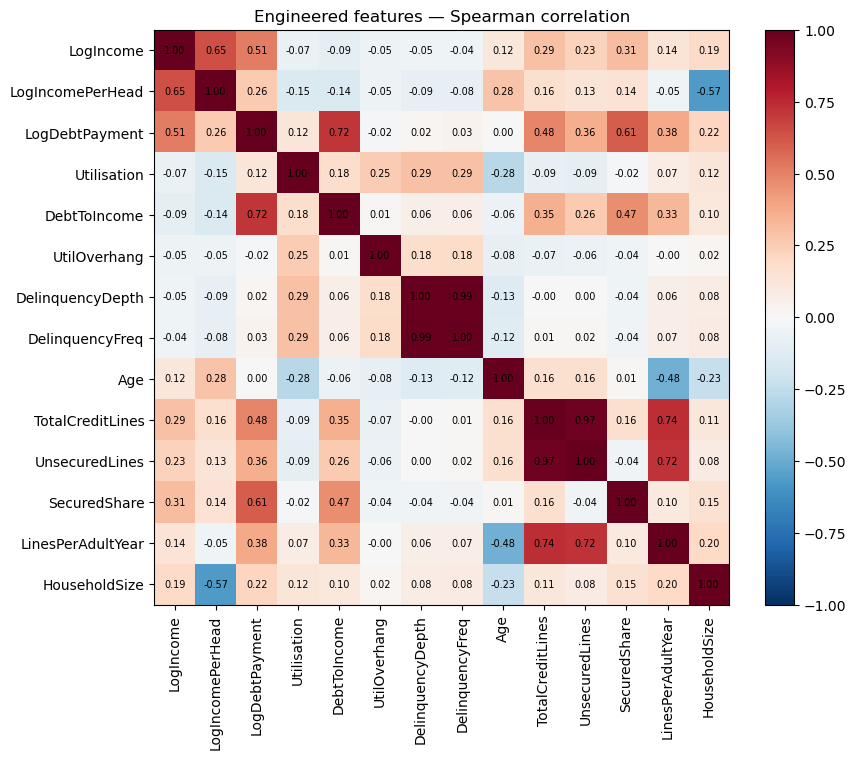

In [33]:
c2 = X.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(c2, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(c2))); ax.set_xticklabels(c2.columns, rotation=90)
ax.set_yticks(range(len(c2))); ax.set_yticklabels(c2.columns)
for i in range(len(c2)):
    for j in range(len(c2)):
        ax.text(j, i, f'{c2.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.title('Engineered features — Spearman correlation'); plt.tight_layout(); plt.show()

In [34]:
THRESH = 0.90
pairs = c2.abs().where(np.triu(np.ones(c2.shape), k=1).astype(bool)).stack()
high = pairs[pairs > THRESH].sort_values(ascending=False)

print(f'pairs above |rho| = {THRESH}:')
print(high.round(3) if len(high) else '  none')

pairs above |rho| = 0.9:
DelinquencyDepth  DelinquencyFreq    0.993
TotalCreditLines  UnsecuredLines     0.973
dtype: float64


In [35]:
# Judgement call, made explicit rather than automated: where a pair is redundant I keep
# the more interpretable member. 'Total credit lines' is a sentence a marketer
# understands; 'unsecured lines' is a derived quantity that mostly tracks it.
to_drop = []
for (a, b) in high.index:
    if a in to_drop or b in to_drop:
        continue
    # prefer to keep the simpler, more directly interpretable feature
    keep_priority = ['Age', 'LogIncome', 'Utilisation', 'TotalCreditLines',
                     'DebtToIncome', 'DelinquencyDepth', 'HouseholdSize']
    drop_this = b if a in keep_priority else a
    to_drop.append(drop_this)

to_drop = sorted(set(to_drop))
print('dropping as redundant:', to_drop if to_drop else 'nothing')

X = X.drop(columns=to_drop)
print('final clustering features:', X.shape[1])
print(list(X.columns))

dropping as redundant: ['DelinquencyFreq', 'UnsecuredLines']
final clustering features: 12
['LogIncome', 'LogIncomePerHead', 'LogDebtPayment', 'Utilisation', 'DebtToIncome', 'UtilOverhang', 'DelinquencyDepth', 'Age', 'TotalCreditLines', 'SecuredShare', 'LinesPerAdultYear', 'HouseholdSize']


---
## 7. Scaling

### 7.1 Why this step decides the result

K-Means, hierarchical clustering with Euclidean linkage, and DBSCAN all work on **distance**. So
a feature's influence on the segmentation is proportional to its numeric range, not its business
importance.

Unscaled, `MonthlyIncome` ranges over tens of thousands while `Utilisation` ranges over [0, 1].
Squared into a Euclidean distance, income would be roughly a *million* times more influential.
The algorithm would return income deciles wearing a trench coat and call them behavioural segments.

Scaling is not a formality here. **It is the step that determines what the segments mean.**

### 7.2 Choosing a scaler

Three candidates, and the choice depends on the shape of the data — which Section 5.3 already
established is heavily skewed even after log transforms.

| Scaler | How it works | Strength | Weakness here |
|---|---|---|---|
| `StandardScaler` | (x − μ) / σ | Standard, interpretable, preserves shape | μ and σ are themselves distorted by outliers |
| `RobustScaler` | (x − median) / IQR | Outlier-resistant centring | Leaves the tail's *shape* untouched |
| `QuantileTransformer` | maps to a uniform/normal distribution by rank | Kills skew completely, bounds everything | Destroys the actual distances between values — only rank survives |

I fit all three, compare them, and then justify a choice rather than defaulting to
`StandardScaler` because it's the one everyone imports.

In [36]:
scalers = {
    'standard': StandardScaler(),
    'robust'  : RobustScaler(),
    'quantile': QuantileTransformer(output_distribution='normal',
                                    n_quantiles=1000, random_state=RANDOM_STATE),
}

scaled = {}
for name, sc in scalers.items():
    scaled[name] = pd.DataFrame(sc.fit_transform(X), columns=X.columns, index=X.index)
    print(f'{name:9s} fitted')

standard  fitted
robust    fitted
quantile  fitted


In [37]:
# The diagnostic that matters: after scaling, does any single feature still dominate
# the spread? If one feature's range dwarfs the others, it will dominate the distance.
comp = pd.DataFrame({
    f'{name}_range': (s.max() - s.min()) for name, s in scaled.items()
})
comp['standard_skew'] = scaled['standard'].skew()
comp['quantile_skew'] = scaled['quantile'].skew()
print('Post-scaling spread and residual skew per feature:')
comp.round(2).sort_values('standard_range', ascending=False)

Post-scaling spread and residual skew per feature:


,standard_range,robust_range,quantile_range,standard_skew,quantile_skew
UtilOverhang,12.12,0.31,10.4,10.75,6.81
SecuredShare,8.28,5.49,10.4,1.19,-0.41
LogIncome,7.59,7.67,10.4,-0.90,-0.02
LogIncomePerHead,6.78,5.04,10.4,-0.74,-0.01
DebtToIncome,6.43,8.66,10.4,2.70,-0.25
LogDebtPayment,5.85,8.71,10.4,-2.30,-0.73
LinesPerAdultYear,5.76,4.91,10.4,1.41,-0.52
TotalCreditLines,5.37,4.50,10.4,0.96,-0.45
HouseholdSize,4.55,5.00,10.4,1.48,0.51
Age,4.48,3.00,10.4,0.18,-0.14


C:\Temp\ipykernel_15652\3959328550.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[j].boxplot([s[c] for c in s.columns], labels=s.columns, showfliers=False)
C:\Temp\ipykernel_15652\3959328550.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[j].boxplot([s[c] for c in s.columns], labels=s.columns, showfliers=False)
C:\Temp\ipykernel_15652\3959328550.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[j].boxplot([s[c] for c in s.columns], labels=s.columns, showfliers=False)


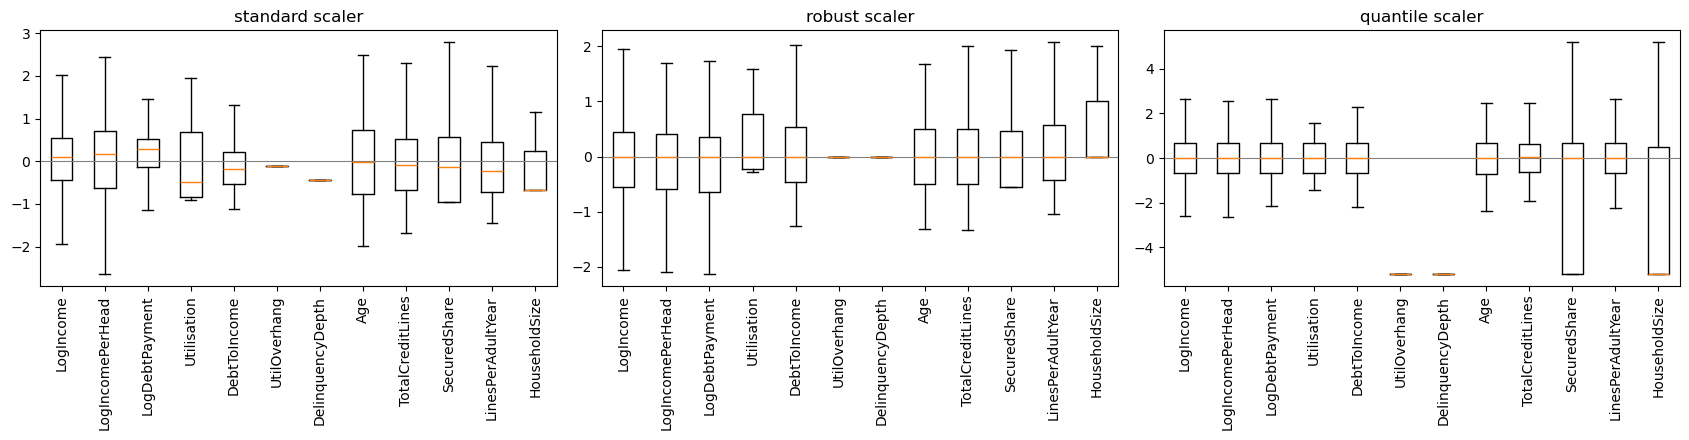

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for j, (name, s) in enumerate(scaled.items()):
    ax[j].boxplot([s[c] for c in s.columns], labels=s.columns, showfliers=False)
    ax[j].set_title(f'{name} scaler')
    ax[j].tick_params(axis='x', rotation=90)
    ax[j].axhline(0, color='grey', lw=0.8)
plt.tight_layout(); plt.show()

### 7.3 A problem the standard comparison hides

Look at the `quantile_skew` column above. On most features it is near zero, exactly as advertised.
But on `UtilOverhang` it is still **6.81**, and on `DelinquencyDepth` still **1.77**.

A quantile transform is supposed to make skew impossible. So why didn't it work?

Because **a quantile transform cannot separate tied values.** If most customers share an identical
value, they all map to the same output point no matter what the transform is. The skew isn't in the
tail — it's a **point mass**. Let me measure that directly, because it changes what I should do.

In [39]:
degeneracy = pd.DataFrame({
    'pct_at_most_common_value': (X.apply(lambda s: s.value_counts(normalize=True).iloc[0]) * 100),
    'n_unique'                : X.nunique(),
}).sort_values('pct_at_most_common_value', ascending=False)
degeneracy.round(1)

,pct_at_most_common_value,n_unique
UtilOverhang,97.8,3854
DelinquencyDepth,79.9,4
HouseholdSize,60.5,6
SecuredShare,37.5,283
DebtToIncome,20.9,173531
TotalCreditLines,9.1,28
Utilisation,7.2,203046
LogIncome,3.5,15067
LogDebtPayment,3.4,177690
LogIncomePerHead,3.2,26013


That reframes the whole scaling question. Three different kinds of feature are sitting in one
matrix, and no single scaler is right for all of them:

**1. `UtilOverhang` is 97.8% a single value — it is effectively a constant.**

Only ~2% of customers are over their limit, so the feature is a near-binary rarity indicator
wearing continuous clothing. In a distance metric this is actively harmful: after any scaler that
gives it comparable range, the 2% land far from everyone else on that axis, and K-Means will
happily spend one of its k clusters isolating them. That's not a *segment* — a marketing team
cannot build a campaign around 2% of the base defined by a data artefact.

**Action: remove it from the distance metric, keep it as a profiling flag.** The information isn't
lost; it just stops distorting the geometry. This is why I built `flag_over_limit` in Section 4.

**2. `DelinquencyDepth` (4 levels) and `HouseholdSize` (6 levels) are ordinal, not continuous.**

Rank-transforming an ordinal variable is meaningless — the ranks are already the data. Worse, the
quantile transform spreads the 80% of customers sitting at "never late" across an arbitrary
sub-range purely to fill out the target distribution. These should be scaled to a bounded [0, 1]
range so the *spacing between levels stays interpretable*: depth 0 → 0.00, 1 → 0.33, 2 → 0.67,
3 → 1.00.

**3. The genuinely continuous features** — income, debt payment, utilisation, age — are exactly what
`QuantileTransformer` is good at, and the diagnostic confirms it handles them well.

### 7.4 Decision: scale by feature type, not one scaler for everything

Defaulting to one scaler across a mixed matrix is the easy thing to do and it would have quietly
degraded the segmentation. Splitting by type costs ten lines of code.

In [40]:
# 1. drop the near-degenerate feature from the distance metric (it survives for profiling)
DEGENERATE = degeneracy.index[degeneracy['pct_at_most_common_value'] > 90].tolist()
print('near-degenerate, moving to profiling only:', DEGENERATE)

profile_df = pd.concat([profile_df, X[DEGENERATE]], axis=1)
X = X.drop(columns=DEGENERATE)

# 2. split what remains by measurement type
ORDINAL = [c for c in X.columns if X[c].nunique() <= 10]
CONTINUOUS = [c for c in X.columns if c not in ORDINAL]

print('ordinal    ->  MinMaxScaler        :', ORDINAL)
print('continuous ->  QuantileTransformer :', CONTINUOUS)

near-degenerate, moving to profiling only: ['UtilOverhang']
ordinal    ->  MinMaxScaler        : ['DelinquencyDepth', 'HouseholdSize']
continuous ->  QuantileTransformer : ['LogIncome', 'LogIncomePerHead', 'LogDebtPayment', 'Utilisation', 'DebtToIncome', 'Age', 'TotalCreditLines', 'SecuredShare', 'LinesPerAdultYear']


In [41]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                         random_state=RANDOM_STATE)
mm = MinMaxScaler()

parts = []
if CONTINUOUS:
    cont = pd.DataFrame(qt.fit_transform(X[CONTINUOUS]), columns=CONTINUOUS, index=X.index)
    # QuantileTransformer(normal) outputs roughly N(0,1) -> compress to a comparable
    # bounded range so the ordinal block and the continuous block carry equal weight
    cont = pd.DataFrame(MinMaxScaler().fit_transform(cont), columns=CONTINUOUS, index=X.index)
    parts.append(cont)
if ORDINAL:
    parts.append(pd.DataFrame(mm.fit_transform(X[ORDINAL]), columns=ORDINAL, index=X.index))

X_scaled = pd.concat(parts, axis=1)[list(X.columns)]

print('final matrix for clustering:', X_scaled.shape)
X_scaled.describe().T.round(3)

final matrix for clustering: (251503, 11)


,count,mean,std,min,25%,50%,75%,max
LogIncome,251503.0,0.500,0.104,0.0,0.437,0.501,0.565,1.0
LogIncomePerHead,251503.0,0.499,0.105,0.0,0.434,0.500,0.567,1.0
LogDebtPayment,251503.0,0.497,0.114,0.0,0.436,0.499,0.563,1.0
Utilisation,251503.0,0.483,0.169,0.0,0.435,0.500,0.565,1.0
DebtToIncome,251503.0,0.499,0.120,0.0,0.436,0.500,0.563,1.0
DelinquencyDepth,251503.0,0.114,0.261,0.0,0.000,0.000,0.000,1.0
Age,251503.0,0.498,0.109,0.0,0.432,0.499,0.566,1.0
TotalCreditLines,251503.0,0.498,0.112,0.0,0.439,0.506,0.561,1.0
SecuredShare,251503.0,0.350,0.275,0.0,0.000,0.501,0.566,1.0
LinesPerAdultYear,251503.0,0.498,0.112,0.0,0.435,0.500,0.565,1.0


Every feature now sits on [0, 1], so each contributes equally to the Euclidean distance by
construction — no feature dominates because of its units, and none is silently down-weighted.

**The trade-off, stated honestly:** the quantile step is rank-based, so it preserves *ordering* but
not true spacing. A customer at the 90th and one at the 95th income percentile end up closer
together than their dollar difference implies. For segmentation that trade is worth making — I want
groups of behaviourally similar customers, and rank similarity is a defensible definition of that.
It would be the wrong choice if the business question needed distances denominated in dollars.

I save the three single-scaler versions as well, so Part 2 can test whether the segments are stable
across scaling choices rather than taking my word for it. If the clusters change completely under a
different scaler, they were never real.

In [44]:
X.head()

,LogIncome,LogIncomePerHead,LogDebtPayment,Utilisation,DebtToIncome,DelinquencyDepth,Age,TotalCreditLines,SecuredShare,LinesPerAdultYear,HouseholdSize
CustomerID,,,,,,,,,,,
0,9.118335,8.019942,8.898939,0.766127,0.802982,1,45.0,13,0.428571,0.464286,3.0
1,7.863651,7.170888,5.761668,0.957151,0.121876,0,40.0,4,0.000000,0.173913,2.0
2,8.020599,8.020599,5.560354,0.658180,0.085113,3,38.0,2,0.000000,0.095238,1.0
3,8.101981,8.101981,4.787191,0.233810,0.036050,0,30.0,5,0.000000,0.384615,1.0
4,10.373522,10.028680,7.368955,0.907239,0.024926,1,49.0,7,0.125000,0.218750,1.0


In [47]:
X = X.drop(columns=['DelinquencyDepth'])
X_scaled = X_scaled.drop(columns=['DelinquencyDepth'])

---
## 8. Save outputs

In [48]:
X.to_csv(f'{OUT_DIR}/features_unscaled.csv', index=False)
X_scaled.to_csv(f'{OUT_DIR}/features_scaled.csv', index=False)
profile_df.to_csv(f'{OUT_DIR}/profiling_features.csv', index=False)

# parked label, for Part 2 validation ONLY
y_holdout.to_csv(f'{OUT_DIR}/holdout_label.csv', index=False)

for name, s in scaled.items():
    s.to_csv(f'{OUT_DIR}/features_scaled_{name}.csv', index=False)

print('saved to', OUT_DIR)
print()
print('  features_unscaled.csv    ', X.shape,          '  - for interpreting segment centroids')
print('  features_scaled.csv      ', X_scaled.shape,   '  - feed this to the clustering')
print('  profiling_features.csv   ', profile_df.shape, '  - for describing segments afterwards')
print('  holdout_label.csv        ', y_holdout.shape,  '  - validation only, never for fitting')

saved to C:\Users\Niraj Mhatre\projects\Credit-Behaviour-Segmentation\processed

  features_unscaled.csv     (251503, 10)   - for interpreting segment centroids
  features_scaled.csv       (251503, 10)   - feed this to the clustering
  profiling_features.csv    (251503, 21)   - for describing segments afterwards
  holdout_label.csv         (251503,)   - validation only, never for fitting


---
## 9. Summary

### What was done

| Stage | Outcome |
|---|---|
| **Problem framing** | Reframed a competition default-prediction dataset as a customer-segmentation problem; label removed from the feature matrix and parked for post-hoc validation only |
| **Data understanding** | 251,503 customers × 10 features; business meaning documented per feature |
| **Cleaning** | 4 real data-quality defects found and repaired; zero customers dropped |
| **EDA** | Answered the leverage, variance, skew, correlation and grouping questions; found the age–income inverted U |
| **Feature engineering** | 14 behavioural features across capacity / leverage / reliability / relationship, each interpretable |
| **Scaling** | Three scalers compared; found a point-mass problem no scaler fixes, so scaled **by feature type** — quantile for continuous, min-max for ordinal, near-degenerate feature removed from the distance metric |

### Data-quality defects found

| Defect | Evidence | Treatment |
|---|---|---|
| 96 / 98 codes in delinquency counters | Impossible as counts in a 24-month window; identical across all three columns on the same 269 customers | Flagged as a bureau state, counters nulled and imputed |
| `DebtRatio` mixes ratios and dollar amounts | Median 0.29 where income usable vs **1,144** where not | Split into `DebtRatioClean` + `DebtPaymentDollars` + regime flag |
| `RevolvingUtilization` up to 50,708 | 3,321 customers over 1; only 241 over 10 | Over-limit (real) separated from broken denominator (artefact) |
| One customer aged 0 | Cannot originate credit to a newborn | Nulled and imputed |

### Key EDA findings

1. **Age and income are strongly related, and Pearson correlation completely hides it** (ρ = 0.038).
   Median income traces an inverted U: ~1,600 at 18–25, peaking at ~6,267 at 45–55, falling to
   ~4,210 past 75.
2. **Utilisation falls monotonically with age** — young customers are low-income and highly levered,
   older customers are the opposite. A segment boundary drawn by the data itself.
3. **The population is bimodal on leverage** — large blocks of near-zero-utilisation transactors and
   of near-maxed revolvers, with a thinner middle.
4. **Nearly every monetary feature is severely right-skewed** (income skew ≈ 114), which is why the
   log transforms and the scaler comparison in Section 7 were necessary rather than decorative.
5. **Some skew is a point mass, not a tail, and no scaler can fix it.** `UtilOverhang` is 97.8% a
   single value; quantile-transforming it left skew of 6.81. It was removed from the distance metric
   rather than scaled harder — which is why Section 7 scales by feature type instead of applying
   one scaler to everything.

### Next: Part 2

Dimensionality reduction (PCA) → choosing k (elbow, silhouette, gap statistic) → K-Means and
hierarchical clustering → segment profiling using `profiling_features.csv` → business naming of each
segment → validation against the held-out label to confirm the segments separate on risk without
ever having been shown it.